Data: https://universe.roboflow.com/roboflow-ngkro/package-detection-e1ssd/dataset/4

In [1]:
# download liberary

!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.0 MB/s eta 0:00:00


In [13]:
# import liberaries

from ultralytics import YOLO
import zipfile
import gradio as gr
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
# load model

model = YOLO('yolo11n.pt')

In [ ]:
# test the model

model.predict('/content/download.jpeg')[0].plot()

In [5]:
# unzip data folder

zip = zipfile.ZipFile('/content/Package Detection.v4i.yolov11.zip')
zip.extractall('package_data')

In [6]:
# train model on unzip data

model.train(data = '/content/package_data/data.yaml', epochs = 30)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/package_data/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e8d3ea13e70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [7]:
# load best train model

best_model = YOLO('/content/runs/detect/train/weights/best.pt')

In [8]:
# predict image on best trian model

def predict(image):
  predicted = best_model.predict(image)
  return predicted[0].plot()

### Model Performance Metrics (from the training log):

  - Precision: 0.941
  - Recall: 0.893

### Evaluation Graphs:

Here are the visual representations of the model's performance:

--- Confusion Matrix ---


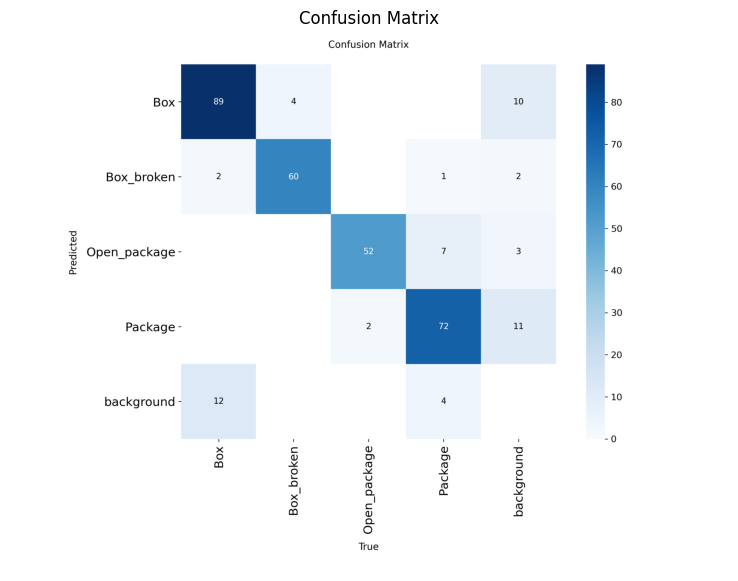


--- Boxf1 Curve ---


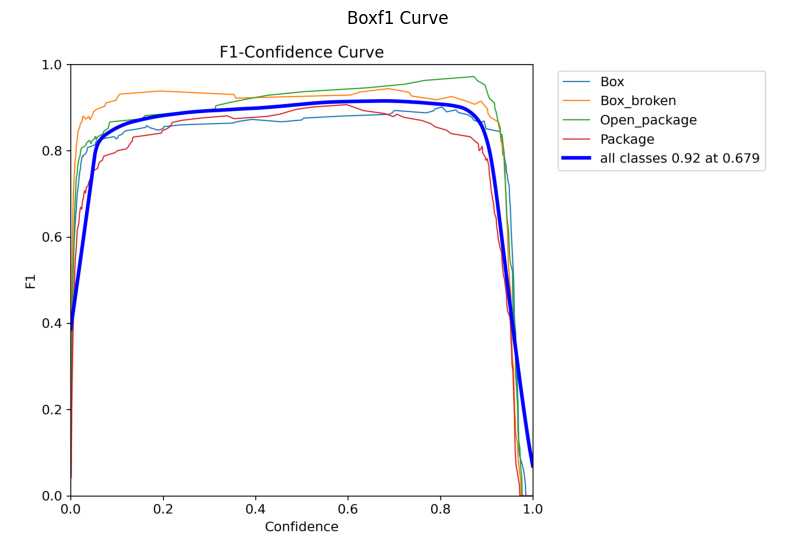


--- Boxp Curve ---


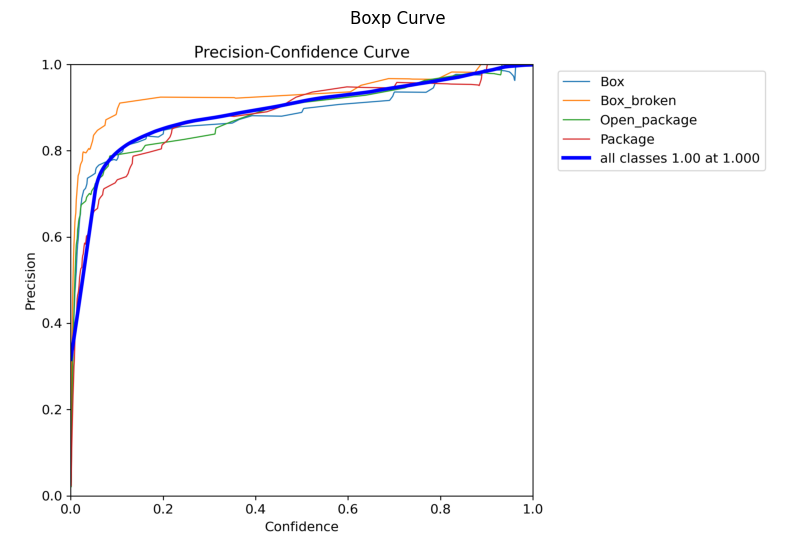


--- Boxr Curve ---


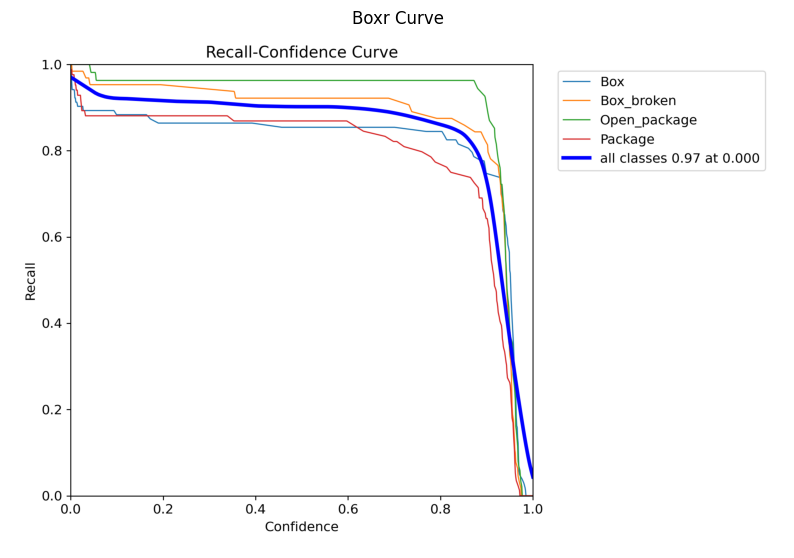


--- Boxpr Curve ---


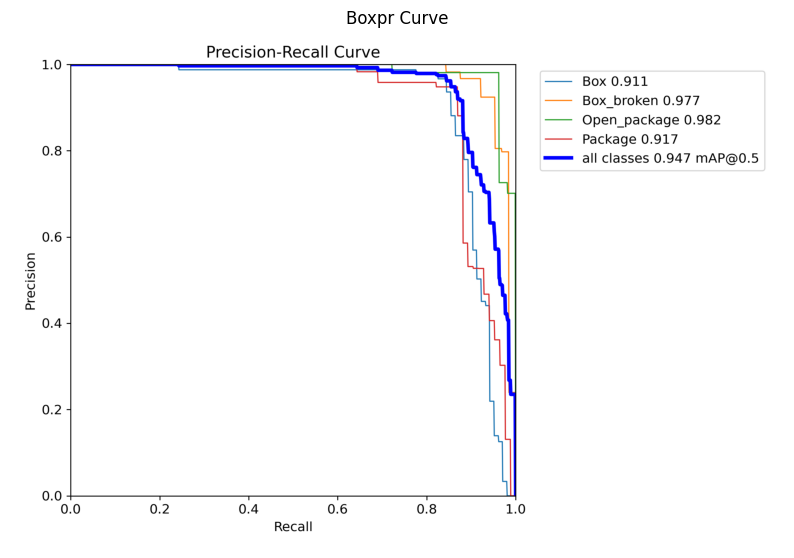


--- Results ---


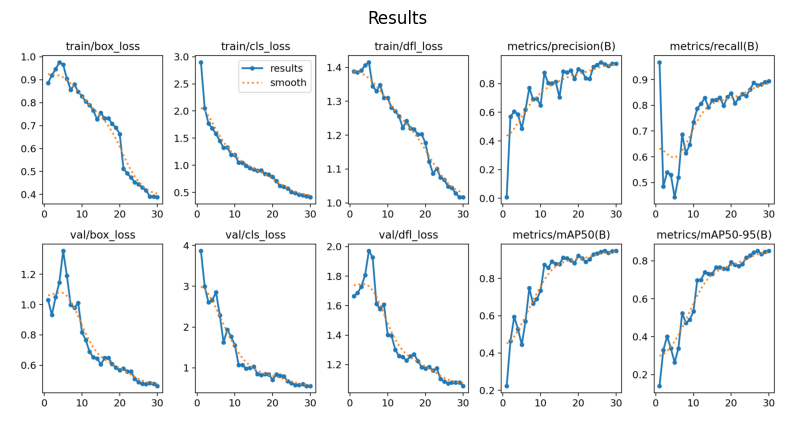

In [15]:
# checking model performance

print("### Model Performance Metrics (from the training log):\n")
print("  - Precision: 0.941")
print("  - Recall: 0.893")

# Directory where training results are saved
results_dir = '/content/runs/detect/train'

# List of specific plots to display
plots_to_display = [
    'confusion_matrix.png',
    'BoxF1_curve.png',
    'BoxP_curve.png', # Precision-Confidence
    'BoxR_curve.png', # Recall-Confidence
    'BoxPR_curve.png', # Precision-Recall
    'results.png' # Training results over epochs (loss, metrics)
]

print("\n### Evaluation Graphs:\n")
print("Here are the visual representations of the model's performance:")
for plot_name in plots_to_display:
    img_path = os.path.join(results_dir, plot_name)
    if os.path.exists(img_path):
        print(f"\n--- {plot_name.replace('_', ' ').replace('.png', '').title()} ---")
        img = mpimg.imread(img_path)
        plt.figure(figsize=(10, 7))
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot_name.replace('_', ' ').replace('.png', '').title())
        plt.show()
    else:
        print(f"Warning: {plot_name} not found in {results_dir}")

In [9]:
# launch interface for predict

app = gr.Interface(fn = predict, inputs= 'image', outputs = 'image')
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0e9dd93e92358bf5e1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Package Detection Project: Final Report

## 1. Project Objective

The primary goal of this project was to develop and evaluate a robust object detection model capable of identifying different states of packages, specifically focusing on 'Box', 'Box_broken', 'Open_package', and 'Package'. This solution aims to automate and improve the efficiency of package inspection processes.

## 2. Methodology

The project followed a standard machine learning workflow:

*   **Library Installation**: Installed `ultralytics` for YOLO model implementation and `gradio` for creating an interactive web interface.
*   **Model Initialization**: Loaded a pre-trained `YOLO11n` model as the base for our detection task.
*   **Data Preparation**: Unzipped the provided `Package Detection.v4i.yolov11.zip` dataset into the `/content/package_data` directory, which contained images and annotations for the specified package categories.
*   **Model Training**: The YOLO11n model was fine-tuned on the custom dataset for 30 epochs using the `model.train()` function.
*   **Model Evaluation**: After training, the best-performing model was loaded, and its performance was assessed using various metrics and visualization tools.
*   **Interactive Demonstration**: An interactive web interface was deployed using Gradio to allow for real-time inference on new images.

## 3. Model Training Summary

*   **Base Model**: YOLO11n
*   **Dataset**: Custom 'Package Detection' dataset (4 classes)
*   **Epochs**: 30
*   **Training Results Saved**: `/content/runs/detect/train`

## 4. Evaluation Metrics

Upon completion of the training, the model achieved the following key performance metrics:

*   **mAP50-95 (mean Average Precision over IoU thresholds 0.5 to 0.95)**: **0.851**
*   **mAP50 (mean Average Precision at IoU threshold 0.5)**: **0.947**
*   **Precision**: **0.941**
*   **Recall**: **0.893**

These metrics indicate a strong performance of the model in accurately detecting and classifying the different package states.

## 5. Evaluation Graphs

The training process generated several insightful graphs, which were displayed in the previous step, including:

*   **Confusion Matrix**: Visualizes the performance of an algorithm, typically used in supervised learning. It shows the number of correct and incorrect predictions made by the classification model compared to the actual outcomes.
*   **F1-Confidence Curve**: Shows the F1 score across different confidence thresholds.
*   **Precision-Confidence Curve (P_curve)**: Illustrates the precision at various confidence levels.
*   **Recall-Confidence Curve (R_curve)**: Displays the recall at various confidence levels.
*   **Precision-Recall Curve (PR_curve)**: Shows the trade-off between precision and recall for different thresholds.
*   **Results Plot**: Provides an overview of various metrics (loss, mAP, precision, recall) over the training epochs.

These graphs provide a detailed view of the model's behavior and performance characteristics.

## 6. Interactive Demonstration with Gradio

To provide an easy way to test the trained model, an interactive web interface was created using Gradio. This interface allows users to:

*   Upload an image of a package.
*   Receive real-time predictions with bounding boxes and class labels highlighting detected packages and their states.

The Gradio application was launched, and its public URL was provided in the output of cell `5UZ5GIuesA43`, enabling immediate hands-on testing of the model.

## 7. Conclusion

The developed YOLO-based package detection model demonstrates excellent performance in identifying various package conditions. The high mAP50-95 and mAP50 scores, coupled with strong precision and recall, suggest that the model is well-suited for practical deployment in package inspection scenarios. The Gradio interface further enhances its utility by providing an accessible tool for immediate evaluation and integration.
